In [1]:
import torch
import torch
from torchvision import datasets, transforms
from torch.utils.data import DataLoader
import matplotlib.pyplot as plt
import vp_sde_chat
from vp_sde_chat import *
import warnings
from Unet import *
import numpy as np
from tqdm import tqdm
warnings.filterwarnings("ignore", category=UserWarning)

In [2]:
from torchvision import datasets, transforms

data_path = r"/mnt/c/Users/Jonat/OneDrive/Dokument/KTH/År 4/P4/DD2424/Projekt/ddpm_replica"

transform = transforms.Compose([
    transforms.ToTensor()
])

train_data = datasets.CIFAR10(
    root=data_path,
    train=True,
    download=False,
    transform=transform
)

test_data = datasets.CIFAR10(
    root=data_path,
    train=False,
    download=False,
    transform=transform
)


train_loader = DataLoader(train_data, batch_size=64, shuffle=True)
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

for images, labels in train_loader:
    images = images.to(device)
    labels = labels.to(device)
    break

In [3]:
def imshow(img):
    img = img / 2 + 0.5
    npimg = img.detach().cpu().numpy()
    plt.imshow(np.transpose(npimg, (1, 2, 0)))
    plt.show()

In [5]:
import torch

def train_vp_sde(
    model,
    sde,
    dataloader,
    lr=1e-4,
    epochs=10,
    device="cuda"
):
    model = model.to(device)
    optimizer = torch.optim.Adam(model.parameters(), lr=lr)
    loss_fn = get_loss_fn(sde)

    model.train()

    loss_history = []   # 🔥 store ALL iteration losses

    for epoch in range(epochs):
        running_loss = 0.0
    
        pbar = tqdm(dataloader, desc=f"Epoch {epoch+1}/{epochs}")
    
        for step, (images, labels) in enumerate(pbar):
            images = images.to(device)
            labels = labels.to(device)
    
            optimizer.zero_grad()
    
            loss = loss_fn(model, images)
    
            loss.backward()
            torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)
            optimizer.step()
    
            loss_history.append(loss.item())
            running_loss += loss.item()
    
            # update tqdm display
            pbar.set_postfix(loss=loss.item())
    
        avg_loss = running_loss / len(dataloader)
        print(f"\nEpoch [{epoch+1}] Avg Loss: {avg_loss:.6f}")

    return model, loss_history

In [6]:
params = {"beta_min" : torch.tensor(0.1, device = device),
          "beta_max" : torch.tensor(20, device = device),
          "time_steps" : torch.tensor(100, device = device)}
vp_sde = VP_SDE(params)

model = UNet()
model = model.to(device)

In [7]:
model, loss_history = train_vp_sde(
    model=model,
    sde=vp_sde,
    dataloader=train_loader,
    lr=1e-4,
    epochs=2,
    device=device
)

Epoch 1/2: 100%|██████████████████████████████████████████████████████████████████████████████████████████████| 782/782 [03:31<00:00,  3.71it/s, loss=0.129]



Epoch [1] Avg Loss: 0.219066


Epoch 2/2: 100%|██████████████████████████████████████████████████████████████████████████████████████████████| 782/782 [03:34<00:00,  3.64it/s, loss=0.214]


Epoch [2] Avg Loss: 0.147854


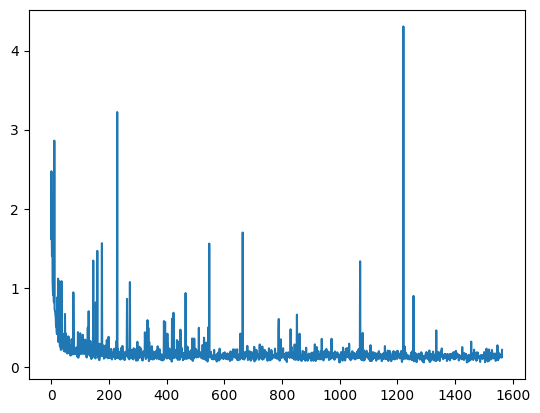

In [10]:
plt.plot(loss_history)

In [13]:
# get batch
images, _ = next(iter(train_loader))
images = images.to(device)

# take one image
x = images[0:1]

# correct score function (IMPORTANT)
score = score_function(model, vp_sde)

eul_for = EulerForward()

# generate sample
img, progress = get_samples(x, score, vp_sde, 1, eul_for, eps=0.01)

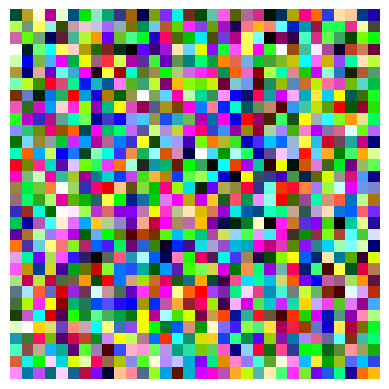

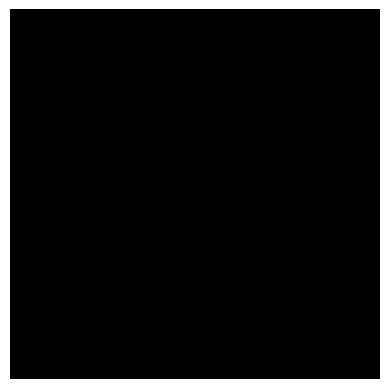

In [19]:
def show(img):
    img = img.squeeze(0).detach().cpu()
    img = (img.clamp(-1, 1) + 1) / 2  # if your model uses [-1,1]
    plt.imshow(img.permute(1, 2, 0))
    plt.axis("off")
    plt.show()

show(progress[0])
show(img)

In [21]:
img.shape

torch.Size([1, 3, 32, 32])